In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pointbiserialr
from scipy.stats import chi2_contingency

sns.set_style("whitegrid")

pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("../dataset/cleaned_data.csv")

In [3]:
churn_rate = (
    df["churned"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

churn_rate

churned
0.0    63.54
1.0    36.46
Name: proportion, dtype: float64

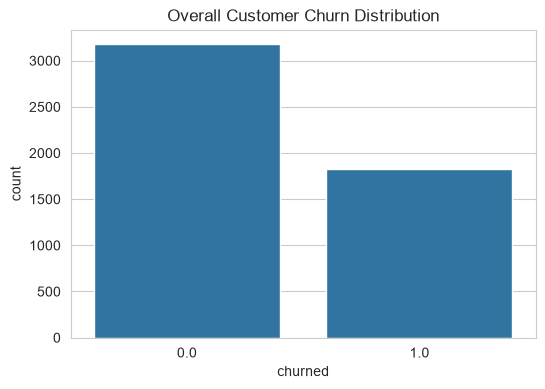

In [4]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="churned"
)

plt.title("Overall Customer Churn Distribution")
plt.show()

In [5]:
numerical_columns = [
    "age",
    "tenure_months",
    "monthly_charges",
    "total_charges",
    "avg_monthly_gb_used",
    "avg_monthly_minutes",
    "num_support_tickets",
    "satisfaction_score"
]

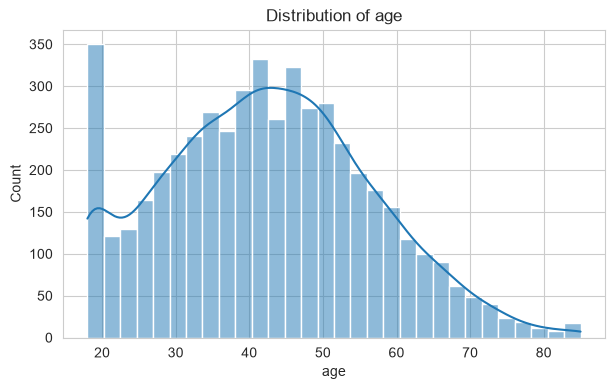

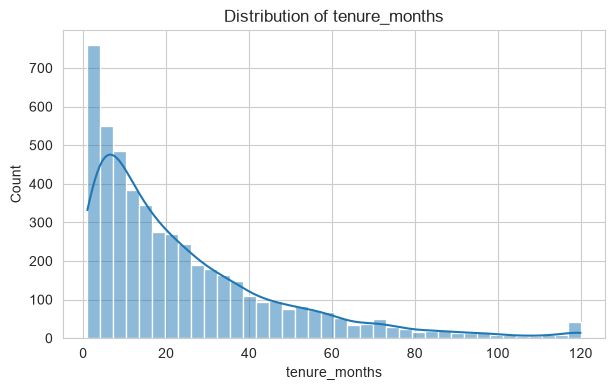

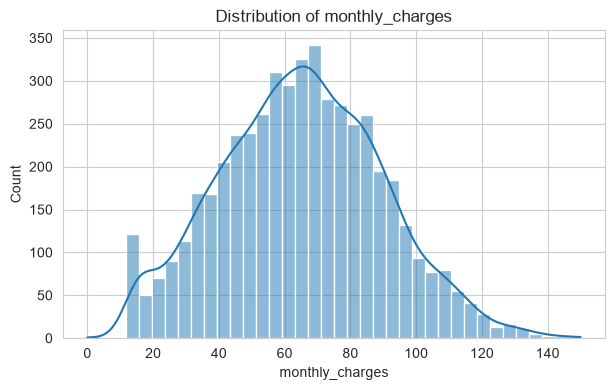

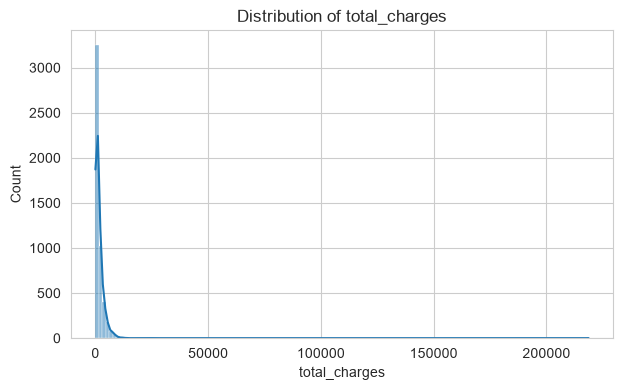

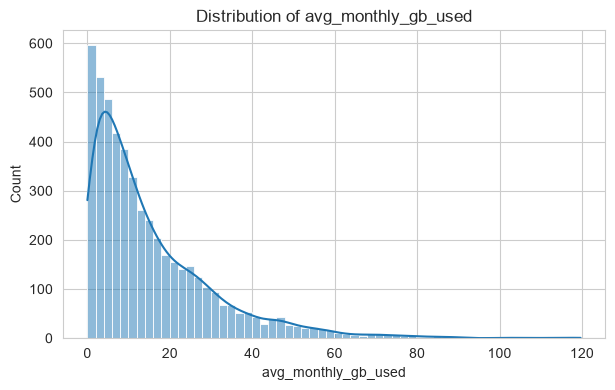

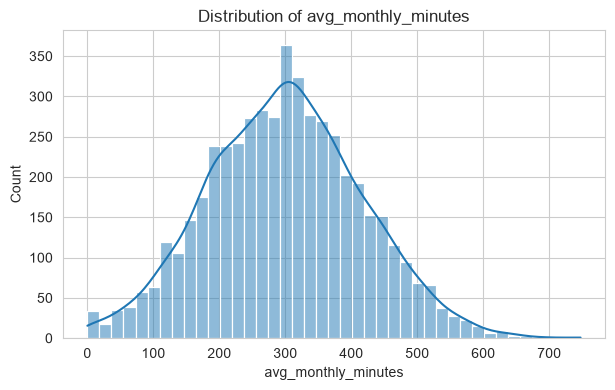

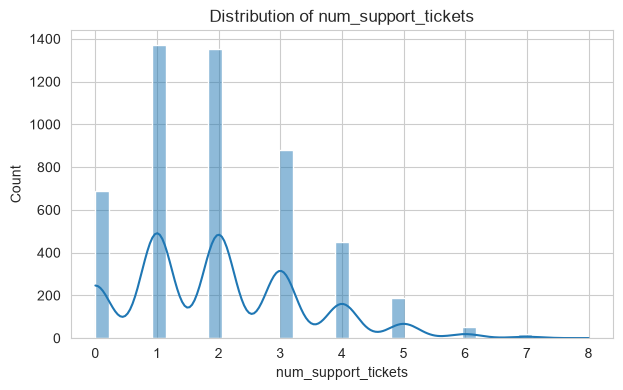

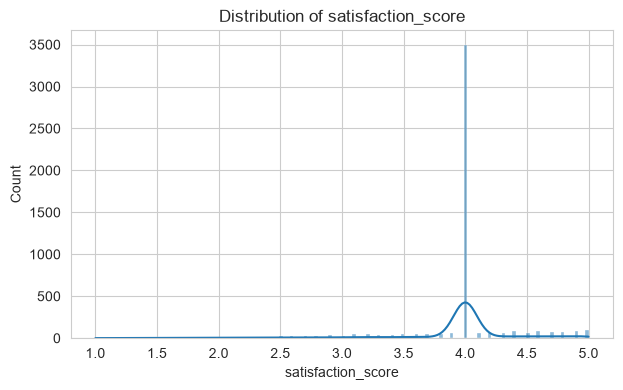

In [6]:
for col in numerical_columns:

    plt.figure(figsize=(7,4))

    sns.histplot(
        data=df,
        x=col,
        kde=True
    )

    plt.title(f"Distribution of {col}")

    plt.show()

## Relationship with Churn

#### Customers with month-to-month contracts appear to churn at a higher rate than customers with longer-term contracts, suggesting contract commitment plays an important role in retention.

<Figure size 800x500 with 0 Axes>

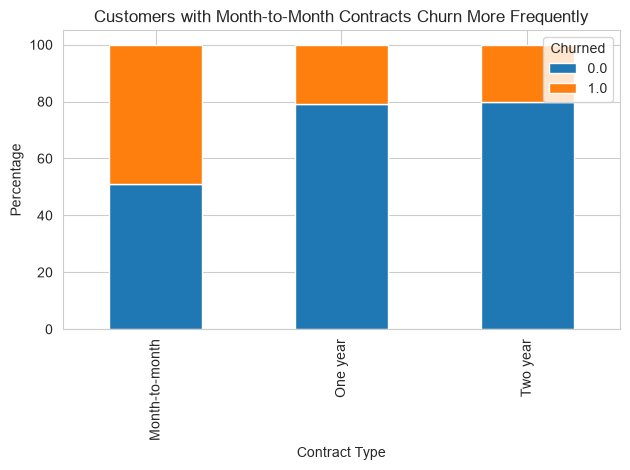

In [7]:
plt.figure(figsize=(8,5))

contract_churn = pd.crosstab(
    df["contract_type"],
    df["churned"],
    normalize="index"
) * 100

contract_churn.plot(kind="bar", stacked=True)

plt.title("Customers with Month-to-Month Contracts Churn More Frequently")
plt.ylabel("Percentage")
plt.xlabel("Contract Type")
plt.legend(title="Churned")
plt.tight_layout()
plt.show()

#### Customers who churn generally have shorter tenure, indicating the first few months of the customer lifecycle are critical for retention.

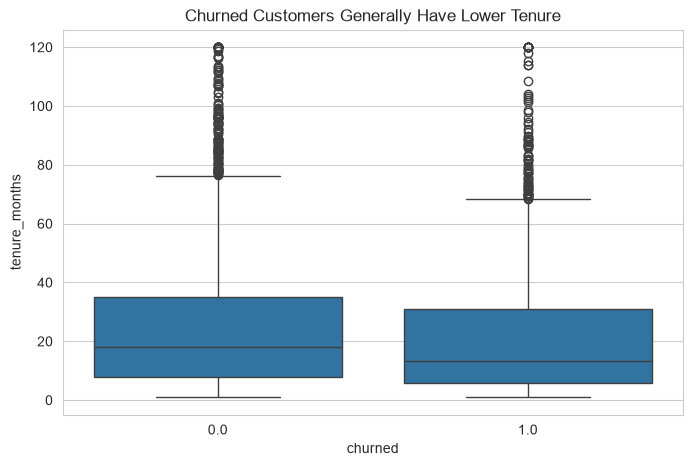

In [8]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="churned",
    y="tenure_months"
)

plt.title("Churned Customers Generally Have Lower Tenure")
plt.show()

#### Customers with lower satisfaction scores are more likely to churn, making satisfaction a strong candidate predictor.

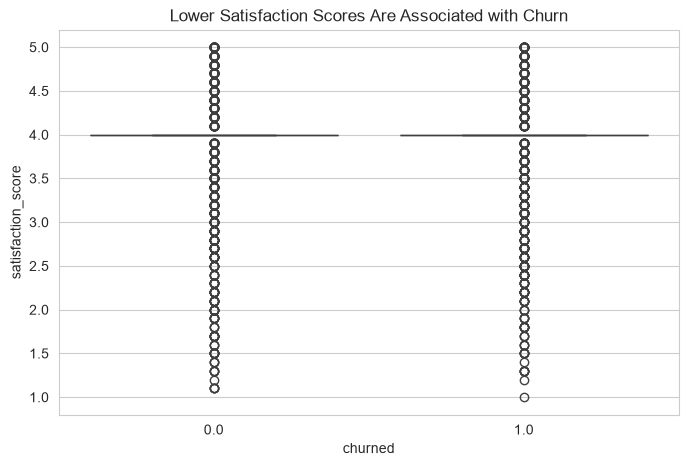

In [9]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="churned",
    y="satisfaction_score"
)

plt.title("Lower Satisfaction Scores Are Associated with Churn")
plt.show()

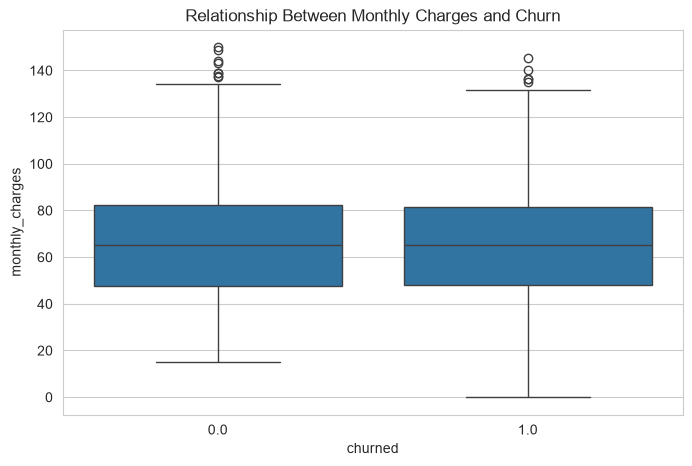

In [10]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="churned",
    y="monthly_charges"
)

plt.title("Relationship Between Monthly Charges and Churn")
plt.show()

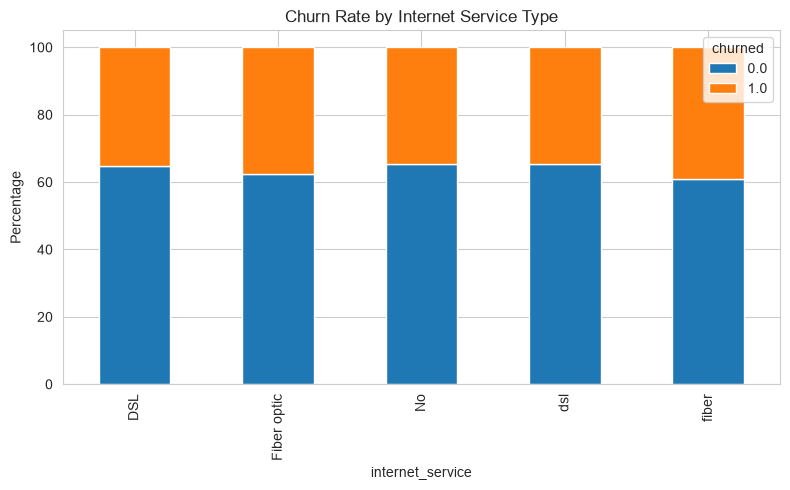

In [11]:
internet_churn = pd.crosstab(
    df["internet_service"],
    df["churned"],
    normalize="index"
) * 100

internet_churn.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5)
)

plt.title("Churn Rate by Internet Service Type")
plt.ylabel("Percentage")
plt.tight_layout()
plt.show()

In [12]:
from scipy.stats import pointbiserialr

numeric_cols = [
    "age",
    "tenure_months",
    "monthly_charges",
    "total_charges",
    "avg_monthly_gb_used",
    "avg_monthly_minutes",
    "num_support_tickets",
    "satisfaction_score",
    "num_additional_services"
]

results = []

for col in numeric_cols:
    corr, p = pointbiserialr(df["churned"], df[col])

    results.append({
        "Feature": col,
        "Correlation": corr,
        "P-value": p
    })

numeric_corr = (
    pd.DataFrame(results)
      .sort_values(
          by="Correlation",
          key=lambda x: abs(x),
          ascending=False
      )
)

numeric_corr

,Feature,Correlation,P-value
1,tenure_months,-0.081618,7.493004e-09
3,total_charges,-0.044613,1.602844e-03
6,num_support_tickets,0.041101,3.652063e-03
7,satisfaction_score,-0.029218,3.883195e-02
5,avg_monthly_minutes,-0.016524,2.427343e-01
4,avg_monthly_gb_used,-0.009516,5.011063e-01
2,monthly_charges,-0.003863,7.847964e-01
0,age,0.003196,8.212782e-01
8,num_additional_services,-0.002729,8.470319e-01


In [13]:
from scipy.stats import chi2_contingency
import numpy as np

categorical_cols = [
    "gender",
    "contract_type",
    "internet_service",
    "phone_service",
    "payment_method"
]

results = []

for col in categorical_cols:

    contingency = pd.crosstab(df[col], df["churned"])

    chi2, p, dof, expected = chi2_contingency(contingency)

    n = contingency.sum().sum()

    cramers_v = np.sqrt(chi2 / (n * (min(contingency.shape)-1)))

    results.append({
        "Feature": col,
        "Chi-Square": round(chi2,2),
        "P-value": round(p,5),
        "Cramers V": round(cramers_v,3)
    })

categorical_corr = pd.DataFrame(results)

categorical_corr.sort_values(
    "Cramers V",
    ascending=False
)

,Feature,Chi-Square,P-value,Cramers V
1,contract_type,425.69,0.00000,0.292
0,gender,8.41,0.03826,0.041
4,payment_method,5.93,0.54745,0.034
2,internet_service,5.07,0.28002,0.032
3,phone_service,0.51,0.47372,0.010


In [14]:
'''For Numerical Features'''
numeric_corr["Score"] = numeric_corr["Correlation"].abs()

numeric_rank = numeric_corr[
    ["Feature","Score"]
]

In [15]:
'''For Categorical Features'''
categorical_rank = categorical_corr.rename(
    columns={
        "Cramers V":"Score"
    }
)[["Feature","Score"]]

In [16]:
feature_ranking = pd.concat(
    [
        numeric_rank,
        categorical_rank
    ],
    ignore_index=True
)

feature_ranking = feature_ranking.sort_values(
    "Score",
    ascending=False
)

feature_ranking.head(5)

,Feature,Score
10,contract_type,0.292000
0,tenure_months,0.081618
1,total_charges,0.044613
2,num_support_tickets,0.041101
9,gender,0.041000


In [17]:
df["charge_per_month"] = (
    df["total_charges"] /
    (df["tenure_months"] + 1)
)

In [18]:
df["support_ticket_rate"] = (
    df["num_support_tickets"] /
    (df["tenure_months"] + 1)
)

# EDA Summary

Key findings from the exploratory analysis:

- Customer churn is moderately imbalanced.
- Customers with shorter tenure exhibit significantly higher churn.
- Lower satisfaction scores strongly correlate with churn.
- Contract type is one of the strongest categorical predictors.
- Monthly charges and support ticket frequency also show meaningful relationships with churn.

Based on these observations, the selected features will be used for model training. Additionally, two engineered features (Charge per Month and Support Ticket Rate) are expected to improve predictive performance by capturing customer spending behavior and service interaction intensity.

# Statistical Association Methods

The target variable (`churned`) is binary, while the dataset contains both numerical and categorical predictors.

- **Point-Biserial Correlation** was used for numerical features because it measures the relationship between a continuous variable and a binary target.
- **Chi-Square Test** was used to determine whether categorical variables are associated with churn.
- **Cramér's V** was calculated to quantify the strength of association for categorical features.

Using different statistical methods for different feature types provides a more appropriate assessment than relying on a single correlation metric.